# 01 - Data validation

Runs the data-quality gate in `DESIGN.md` section 9 before any analysis. The panel is
trusted only after it passes, because administrative series carry breaks and revisions
that can imitate a treatment effect.

Checks here:

1. **Shape and balance**: 16 states x 28 winter semesters, no gaps, no duplicates.
2. **Treatment consistency**: flags in the panel match `data/treatment/fee_dates.csv`.
3. **Reconciliation**: state counts sum to sensible national totals.
4. **Structural breaks**: the 2016 Hochschulstatistikgesetz amendment changed how students
   at multi-site institutions are counted; a level shift there would contaminate any
   window crossing it.
5. **Double cohorts**: the G8 reform years, which are large state-specific shocks.

Mechanics live in `src/validate.py`; the reading of the results is here.

In [17]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "data" / "processed" / "panel.parquet").exists():
            return cand
    raise FileNotFoundError("panel.parquet not found. Run: py src/build_panel.py")

ROOT = find_root()
sys.path.insert(0, str(ROOT))
FIG = ROOT / "results" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
TAB = ROOT / "results" / "tables";  TAB.mkdir(parents=True, exist_ok=True)

from src import validate as v

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

panel = pd.read_parquet(ROOT / "data" / "processed" / "panel.parquet")
fees = pd.read_csv(ROOT / "data" / "treatment" / "fee_dates.csv", dtype={"state_code": str})
print(f"{len(panel)} rows, {panel.state_code.nunique()} states, "
      f"{panel.year.min()}-{panel.year.max()}")
panel.head()

448 rows, 16 states, 1998-2025


,state,state_en,state_code,year,term_label,first_years_location,ever_treated,intro_year,abolish_year,treated,event_time,event_time_abolition,cohort,east,city_state,double_abitur_year,double_cohort_year
0,Schleswig-Holstein,Schleswig-Holstein,01,1998,WS 1998/99,5127,0,<NA>,<NA>,0,<NA>,<NA>,0,0,0,2016,0
1,Schleswig-Holstein,Schleswig-Holstein,01,1999,WS 1999/00,5259,0,<NA>,<NA>,0,<NA>,<NA>,0,0,0,2016,0
2,Schleswig-Holstein,Schleswig-Holstein,01,2000,WS 2000/01,5881,0,<NA>,<NA>,0,<NA>,<NA>,0,0,0,2016,0
3,Schleswig-Holstein,Schleswig-Holstein,01,2001,WS 2001/02,6573,0,<NA>,<NA>,0,<NA>,<NA>,0,0,0,2016,0
4,Schleswig-Holstein,Schleswig-Holstein,01,2002,WS 2002/03,6690,0,<NA>,<NA>,0,<NA>,<NA>,0,0,0,2016,0


## 1. Shape and balance

In [18]:
shape = v.check_balanced(panel)
for k, val in shape.items():
    print(f"{k:24s}: {val}")

assert shape["balanced"], "panel is not balanced"
assert shape["duplicate_unit_periods"] == 0, "duplicate state-period rows"

print("\nmissing values per column:")
print(v.check_missing(panel).to_string())

units                   : 16
periods                 : 28
expected_rows           : 448
actual_rows             : 448
balanced                : True
duplicate_unit_periods  : 0

missing values per column:
state                     0
state_en                  0
state_code                0
year                      0
term_label                0
first_years_location      0
ever_treated              0
intro_year              252
abolish_year            252
treated                   0
event_time              252
event_time_abolition    252
cohort                    0
east                      0
city_state                0
double_abitur_year       84
double_cohort_year        0


## 2. Treatment consistency

The panel's flags must agree with the hand-coded source table.

In [19]:
cons = v.check_treatment_consistency(panel, fees)
print(cons)
assert cons["match"], "treatment flags disagree with fee_dates.csv"

print("\ncharged spells implied by the panel (first and last charged winter semester):")
spells = (panel[panel.treated == 1]
          .groupby("state")["year"].agg(first="min", last="max", n_terms="count"))
print(spells.to_string())

print("\nnever-treated states:",
      ", ".join(sorted(panel.loc[panel.cohort == 0, "state"].unique())))

{'match': True, 'in_panel_only': [], 'in_table_only': []}

charged spells implied by the panel (first and last charged winter semester):
                     first  last  n_terms
state                                    
Baden-Wuerttemberg    2007  2011        5
Bayern                2007  2012        6
Hamburg               2007  2011        5
Hessen                2007  2007        1
Niedersachsen         2006  2013        8
Nordrhein-Westfalen   2006  2010        5
Saarland              2007  2009        3

never-treated states: Berlin, Brandenburg, Bremen, Mecklenburg-Vorpommern, Rheinland-Pfalz, Sachsen, Sachsen-Anhalt, Schleswig-Holstein, Thueringen


## 3. Reconciliation

National first-years summed from the states. There is no independent published series in
this repo to diff against, so this is a plausibility check: the level should be in the
right order of magnitude and the series should move smoothly except where a known event
explains a jump.

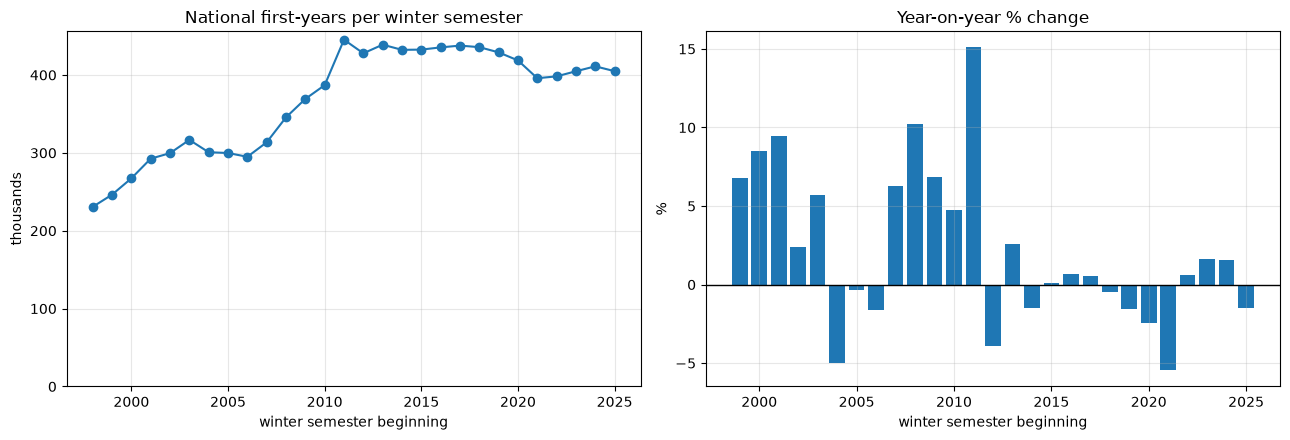

 year  first_years_location  pct_change
 1998                230670         NaN
 1999                246318         6.8
 2000                267295         8.5
 2001                292556         9.5
 2002                299649         2.4
 2003                316656         5.7
 2004                300793        -5.0
 2005                299839        -0.3
 2006                294946        -1.6
 2007                313540         6.3
 2008                345625        10.2
 2009                369273         6.8
 2010                386921         4.8
 2011                445320        15.1
 2012                427825        -3.9
 2013                438913         2.6
 2014                432280        -1.5
 2015                432589         0.1
 2016                435427         0.7
 2017                437737         0.5
 2018                435731        -0.5
 2019                429049        -1.5
 2020                418697        -2.4
 2021                395845        -5.5


In [20]:
nat = v.check_national_totals(panel)
nat["pct_change"] = nat["first_years_location"].pct_change() * 100

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(nat["year"], nat["first_years_location"] / 1000, marker="o")
ax[0].set_ylim(0, None)
ax[0].set_title("National first-years per winter semester")
ax[0].set_xlabel("winter semester beginning"); ax[0].set_ylabel("thousands")

ax[1].bar(nat["year"], nat["pct_change"])
ax[1].axhline(0, color="black", lw=1)
ax[1].set_title("Year-on-year % change")
ax[1].set_xlabel("winter semester beginning"); ax[1].set_ylabel("%")

plt.tight_layout()
plt.savefig(FIG / "01_national_reconciliation.png", dpi=130, bbox_inches="tight")
plt.show()

print(nat.to_string(index=False, float_format=lambda x: f"{x:10.1f}"))

**Read for:** a level in the plausible range (a few hundred thousand first-years per
winter semester nationally), and any single-year jump too large to be demographic.

## 4. Structural break: the 2016 Hochschulstatistikgesetz

The counting rules changed in 2016. If that produced a level shift, any estimation window
crossing it is contaminated. The introduction window used for the main analysis ends well
before 2016, so this is a check on the wider panel rather than on the primary
specification.

In [21]:
brk = v.check_structural_breaks(panel, "first_years_location")
window = brk[(brk.year >= 2012) & (brk.year <= 2019)]
print(window.to_string(index=False, float_format=lambda x: f"{x:10.1f}"))

typical = brk.loc[(brk.year >= 2000) & (brk.year <= 2019), "pct_change"].abs().median()
at_2016 = float(brk.loc[brk.year == 2016, "pct_change"].iloc[0])
print(f"\nmedian |pct change| 2000-2019 : {typical:.2f}%")
print(f"pct change at 2016            : {at_2016:.2f}%")
print("flag" if abs(at_2016) > 3 * typical else "no unusual break at 2016")

 year  first_years_location  pct_change
 2012                427825        -3.9
 2013                438913         2.6
 2014                432280        -1.5
 2015                432589         0.1
 2016                435427         0.7
 2017                437737         0.5
 2018                435731        -0.5
 2019                429049        -1.5

median |pct change| 2000-2019 : 3.26%
pct change at 2016            : 0.66%
no unusual break at 2016


## 5. Double cohorts (G8)

Each state that shortened Gymnasium produced one double Abitur cohort: a one-off surge in
school leavers unrelated to fees. These are recorded in `data/treatment/g8_dates.csv` and
are the largest known confounder in this window.

In [22]:
g8 = panel[["state", "state_code", "double_abitur_year"]].drop_duplicates()
print("double Abitur years:")
print(g8.dropna().sort_values("double_abitur_year").to_string(index=False))

# how large is a double-cohort year relative to a state's own trend?
p = panel.copy()
p["yoy"] = p.groupby("state_code")["first_years_location"].pct_change() * 100
dbl = p[p.double_cohort_year == 1][["state", "year", "yoy"]]
oth = p[(p.double_cohort_year == 0) & p.yoy.notna()]["yoy"]
print("\nyear-on-year % change in double-cohort years:")
print(dbl.to_string(index=False, float_format=lambda x: f"{x:8.1f}"))
print(f"\nmedian |yoy| in all other state-years: {oth.abs().median():.1f}%")

double Abitur years:
                 state state_code  double_abitur_year
        Sachsen-Anhalt         15                2007
Mecklenburg-Vorpommern         13                2008
              Saarland         10                2009
               Hamburg         02                2010
                Bayern         09                2011
         Niedersachsen         03                2011
    Baden-Wuerttemberg         08                2012
                Bremen         04                2012
           Brandenburg         12                2012
                Berlin         11                2012
                Hessen         06                2013
   Nordrhein-Westfalen         05                2013
    Schleswig-Holstein         01                2016

year-on-year % change in double-cohort years:
                 state  year      yoy
    Schleswig-Holstein  2016     10.8
               Hamburg  2010      4.1
         Niedersachsen  2011     21.4
                Bremen  

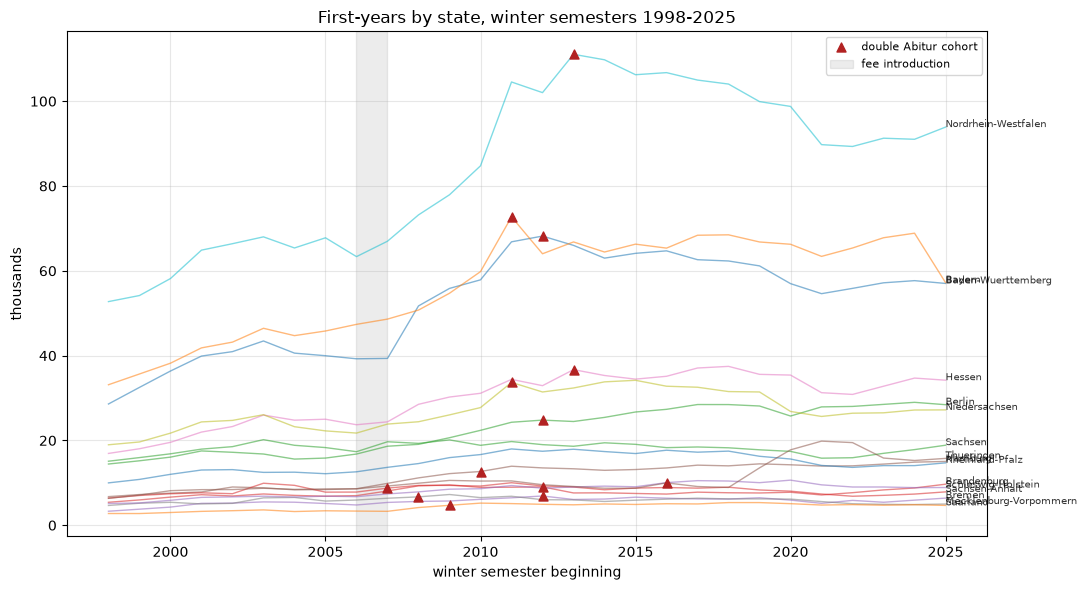

In [23]:
fig, ax = plt.subplots(figsize=(11, 6))
for st, g in panel.groupby("state"):
    ax.plot(g["year"], g["first_years_location"] / 1000, alpha=0.55, lw=1)
    ax.annotate(st, (g["year"].iloc[-1], g["first_years_location"].iloc[-1] / 1000),
                fontsize=7, alpha=0.8)
d = panel[panel.double_cohort_year == 1]
ax.scatter(d["year"], d["first_years_location"] / 1000, s=42, marker="^",
           color="firebrick", zorder=5, label="double Abitur cohort")
ax.axvspan(2006, 2007, color="grey", alpha=0.15, label="fee introduction")
ax.set_title("First-years by state, winter semesters 1998-2025")
ax.set_xlabel("winter semester beginning"); ax.set_ylabel("thousands")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "02_states_with_double_cohorts.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Save the validation summary

In [24]:
summary = pd.DataFrame([
    {"check": "balanced panel", "result": shape["balanced"]},
    {"check": "no duplicate state-periods", "result": shape["duplicate_unit_periods"] == 0},
    {"check": "no missing outcomes",
     "result": int(panel["first_years_location"].isna().sum()) == 0},
    {"check": "treatment matches fee_dates.csv", "result": cons["match"]},
    {"check": "7 treated / 9 never-treated",
     "result": (panel[panel.cohort > 0].state.nunique() == 7
                and panel[panel.cohort == 0].state.nunique() == 9)},
    {"check": "no 2016 break beyond 3x typical", "result": abs(at_2016) <= 3 * typical},
])
summary.to_csv(TAB / "01_validation_summary.csv", index=False)
print(summary.to_string(index=False))
print(f"\nsaved to {TAB/'01_validation_summary.csv'}")

                          check  result
                 balanced panel    True
     no duplicate state-periods    True
            no missing outcomes    True
treatment matches fee_dates.csv    True
    7 treated / 9 never-treated    True
no 2016 break beyond 3x typical    True

saved to C:\Users\wassi\Desktop\tuition-fees-causal-impact\results\tables\01_validation_summary.csv


## Gate decision

**Passed**, with two conditions carried into the analysis.

All six checks returned True: the panel is balanced (16 states x 28 winter semesters, 448
rows), there are no duplicate state-periods, no missing outcomes, the treatment flags
agree with `fee_dates.csv`, the 7/9 treated-to-never-treated split holds, and there is no
definitional break at 2016 (0.66% against a typical 3.26%).

**Reconciliation is plausible.** National first-years rise from about 231k in WS 1998/99 to
a peak of 445k in 2011, then settle near 405k. The +15.1% jump in 2011 is the Bayern and
Niedersachsen double cohorts arriving together, which is the expected signature rather
than an anomaly.

### Condition 1: Sachsen-Anhalt's 2007 double cohort contaminates the control group

The double cohorts are large. Median year-on-year change is **4.2%** in ordinary
state-years but reaches **21.6%** (Bayern 2011), **21.4%** (Niedersachsen 2011), **12.6%**
(Saarland 2009) and **11.9%** (Sachsen-Anhalt 2007) in double-cohort years, two to five
times normal volatility.

One of those lands badly. **Sachsen-Anhalt is a never-treated control state, and its double
cohort falls in 2007**, the first winter semester in which all seven treated states are
charging fees. A large positive idiosyncratic shock in the control group at exactly the
treatment date inflates the counterfactual and **biases the estimated fee effect away from
zero**, in the direction of appearing larger than it is.

This is not a nuisance to note in passing. In the introduction window the effect is
therefore estimated three ways and all three are reported:

1. baseline, all states;
2. excluding Sachsen-Anhalt;
3. with a double-cohort indicator as a control.

If the estimate moves materially between these, that instability is the finding.

### Condition 2: the G8 dates need verification before they are relied upon

Every row of `data/treatment/g8_dates.csv` is still marked `VERIFY`, and three entries look
doubtful because their double-cohort year shows little movement: Baden-Wuerttemberg 2012
(+2.0%), Berlin 2012 (+2.1%) and Brandenburg 2012 (+0.9%), against the 11-21% seen in
cohorts we are confident about. Either the year is wrong for those states or their reform
was phased rather than a single cohort. These must be checked against primary sources
before the double-cohort control is used in estimation.

Nothing was excluded from the panel at this stage; both conditions are applied in the
analysis notebooks, where their effect on the estimate can be seen.

Next: `02_eda.ipynb`.